In [17]:
import importlib.metadata

# List the distribution package names
packages = ["langchain", "langchain-community", "langchain-openai", 
           "langchain-text-splitters", "pypdf", "pinecone"]

for package in packages:
    try:
        version = importlib.metadata.version(package)
        print(f"{package} version: {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{package} is not installed in this environment.")

# langchain version: 1.3.6
# langchain-community version: 0.4.2
# langchain-openai version: 1.2.2
# langchain-text-splitters version: 1.1.2
# pypdf version: 6.10.2
# pinecone version: 7.3.0


langchain version: 1.3.6
langchain-community version: 0.4.2
langchain-openai version: 1.2.2
langchain-text-splitters version: 1.1.2
pypdf version: 6.10.2
pinecone version: 7.3.0


In [9]:
from dotenv import load_dotenv
import os

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
PINECONE_INDEX = 'loxford-quantum-mechanics'

EMBEDDING_MODEL = "text-embedding-3-small"
LLM_MODEL = "gpt-4o-mini"

TOP_K = 3

In [10]:
############################################################
# Imports
############################################################

from typing import TypedDict

from dotenv import load_dotenv
import os

from pinecone import Pinecone

from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings

from langchain_pinecone import PineconeVectorStore

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate


# Retriever

In [11]:
# Connect to Pinecone

pc = Pinecone(api_key=PINECONE_API_KEY)

index = pc.Index(PINECONE_INDEX)


# Embedding Model

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENAI_API_KEY
)


# Existing Pinecone Vector Store
vector_store = PineconeVectorStore(
    index=index,
    embedding=embeddings,
    text_key="text"
)


# Retriever
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 3
    }
)


In [12]:
# LLM

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
    api_key=OPENAI_API_KEY
)

# Prompt

prompt = ChatPromptTemplate.from_template(
"""
You are a helpful AI assistant.

Answer ONLY from the supplied context.

If the answer cannot be found in the context,
reply exactly:

I don't know.

-------------------------

Context:  
{context}

-------------------------

Question: 
{question}
"""
)


# Graph State
class GraphState(TypedDict):
    question: str
    documents: list[Document]
    answer: str


# Retrieve Node
def retrieve(state: GraphState):
    documents = retriever.invoke( state["question"] )
    return { "documents": documents }


# Generate Node
def generate(state: GraphState):
    context = "\n\n".join(
        doc.page_content
        for doc in state["documents"]
    )

    messages = prompt.invoke(
        {
            "context": context,
            "question": state["question"]
        }
    )

    response = llm.invoke(messages)

    return { "answer": response.content }

In [13]:
# Build Graph

graph = StateGraph(GraphState)

graph.add_node("retrieve", retrieve)
graph.add_node("generate", generate)
graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "generate")
graph.add_edge("generate", END)


# Compile Graph
rag_graph = graph.compile()

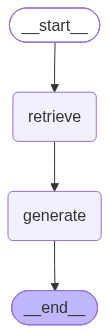

In [14]:
from IPython.display import Image, display

display( Image( rag_graph.get_graph().draw_mermaid_png() ))

In [15]:
# Example

query = "Who are the founders of Loxford Academy?"

result = rag_graph.invoke( {"question": query} )

# Print Answer

print("\nAnswer\n", result["answer"])


Answer
 The founders of Loxford Academy are Alberto Graciaso Negurasa and Rohit Salvadore Lomax.


In [16]:

# Print Sources
print("\nRetrieved Documents\n")

for i, doc in enumerate(result["documents"], start=1):

    print("=" * 60)
    print(f"Document {i}")
    print("\nMetadata:", doc.metadata)
    print("\nContent:", doc.page_content)

    print()


Retrieved Documents

Document 1

Metadata: {'chunk_id': 3.0, 'page': 1.0, 'source': 'Quantum Mechanics-LoxfordAcademy-small.pdf'}

Content: Loxford Academy: 
Loxford Academy was founded by Alberto Graciaso Negurasa and Rohit Salvadore Lomax. 
Its address is 5432, Deru Valley on planet Mars.  Loxford Academy has 34,000 employees 
and has a revenue of 99 million dollars. Its employee workforce consists of citizen from  
Australia, India, USA, Europe, and many other countries. Its headquarter is in Honda Valley 
located on Mars.

Document 2

Metadata: {'chunk_id': 1.0, 'page': 0.0, 'source': 'Quantum Mechanics-LoxfordAcademy-small.pdf'}

Content: concise introduction: we’ll define quantum mechanics, outline its history with a timeline, 
meet two pioneers (Max Planck and Erwin Schrödinger) via short bios and a comparison 
table, then unpack essential quantum concepts (wave–particle duality, superposition, 
uncertainty, quantization, quantum states/operators, measurement, entanglement, spi